In [ ]:
# Samples with all cosmic particles are generated by ../trigger/run_cosmic_all.sh
# 100 runs of 500000 event each are generated (~0.5s of exposure for each run)

In [1]:
import sys

import ROOT
import numpy as np
import matplotlib.pylab as plt
import tqdm


sys.path.append("../../../python")
from simhelper import util, root, generator, parser
from simhelper import datatypes
from simhelper import helper_basic as hp
from simhelper import helper_plt as hplt

Welcome to JupyROOT 6.28/10


In [2]:
sim_data_dir = "/project/6075887/MATHUSLA/simulation/"


In [3]:
# Check simulation raw file
filename = f"{sim_data_dir}/cosmic/cosmic_all/run_9.root"
tfile=ROOT.TFile(filename)
Tree = tfile.Get('metadata')
Tree.GetEntry(0)
print(Tree.GenReserved1)

Real time simulated:0.505785


In [4]:
filename = f"{sim_data_dir}/cosmic/cosmic_all/run_98_digi_recon.root"

tfile=ROOT.TFile(filename)
print([i.GetName() for i in tfile.GetListOfKeys()])
tree_name = tfile.GetListOfKeys()[0].GetName()
Tree = tfile.Get(tree_name)
entries = Tree.GetEntries()
branches = [Tree.GetListOfBranches()[i].GetName() for i in range(len(Tree.GetListOfBranches()))]
tfile.ls()
print(entries, branches)

['data', 'metadata', 'metadata_digi', 'metadata_recon']
218718 ['SimEntry', 'Track_x0', 'Track_y0', 'Track_z0', 'Track_t0', 'Track_kx', 'Track_ky', 'Track_kz', 'Track_kt', 'Track_cov', 'Track_chi2', 'Track_id', 'Track_iv_ind', 'Track_iv_err', 'Track_digiInds', 'Vertex_x0', 'Vertex_y0', 'Vertex_z0', 'Vertex_t0', 'Vertex_cov', 'Vertex_chi2', 'Vertex_id', 'Vertex_trackInds', 'Vertex_tracklet_n0', 'Vertex_tracklet_n2', 'Vertex_tracklet_n3', 'Vertex_tracklet_n4p', 'Digi_x', 'Digi_y', 'Digi_z', 'Digi_t', 'Digi_edep', 'Digi_trackID', 'Digi_pdgID', 'Digi_detectorID', 'Digi_type', 'Digi_hitInds', 'Digi_direction', 'Run_number', 'Evt_number', 'Seed_0', 'Seed_1', 'Hit_x', 'Hit_y', 'Hit_z', 'Hit_t', 'Hit_edep', 'Hit_px', 'Hit_py', 'Hit_pz', 'Hit_trackID', 'Hit_trackIDparent', 'Hit_pdgID', 'Hit_pdgIDparent', 'Hit_isprimary', 'Hit_processID', 'Hit_detectorID', 'Gen_x', 'Gen_y', 'Gen_z', 'Gen_t', 'Gen_px', 'Gen_py', 'Gen_pz', 'Gen_pdgID', 'Gen_index', 'Step_x', 'Step_y', 'Step_z', 'Step_t', 'Step_ede

In [35]:

def vector2list(vector):
    return [vector.at(i) for i in range(vector.size())]    

def process_tree(Tree):
    
    rq_keys = ["n_cosmic","n_muon", "n_np", "n_vertex", "n_track", "n_track_downward", "n_vertex_upward"]
    rq = {key:[] for key in rq_keys}
    for i in tqdm.tqdm(range(Tree.GetEntries())):
        Tree.GetEntry(i)
        Gen_pdgID = np.array(vector2list(Tree.Gen_pdgID))
        Vertex_id = vector2list(Tree.Vertex_id)
        Vertex_trackInds = util.unzip(vector2list(Tree.Vertex_trackInds))
        Track_vz = np.array(vector2list(Tree.Track_kt))
        
        rq["n_cosmic"].append(len(Gen_pdgID))
        rq["n_muon"].append(sum(abs(Gen_pdgID)==13))
        rq["n_np"].append(sum((abs(Gen_pdgID)==2212) | (abs(Gen_pdgID)==2112)))
        rq["n_vertex"].append(len(Vertex_trackInds))
        rq["n_track"].append(len(Tree.Track_x0))
        rq["n_track_downward"].append(sum(Track_vz<0))
    
        if len(Vertex_trackInds)==0:
            rq["n_vertex_upward"].append(len(Vertex_trackInds))
        else:
            n_up = 0
            for track_inds in Vertex_trackInds:
                n_down = sum(Track_vz[track_inds]<0)
                if n_down ==0:
                    n_up+=1
            rq["n_vertex_upward"].append(n_up)
                    
            
    for key in rq:
        rq[key] = np.array(rq[key])   
    return rq

In [37]:
rq=None
for ifile in range(100):
    
    filename = f"{sim_data_dir}/cosmic/cosmic_all/run_{ifile}_digi_recon.root"
    
    tfile=ROOT.TFile(filename)
    tree_name = tfile.GetListOfKeys()[0].GetName()
    Tree = tfile.Get(tree_name)
    rq_tmp = process_tree(Tree)
    if rq is None:
        rq=rq_tmp
    else:
        for key in rq:
            rq[key] = np.concatenate((rq[key], rq_tmp[key]))

100%|██████████| 219126/219126 [00:08<00:00, 27205.48it/s]


In [40]:
import joblib
# joblib.dump(rq, f"{sim_data_dir}/cosmic/cosmic_all/rq_merged.joblib")

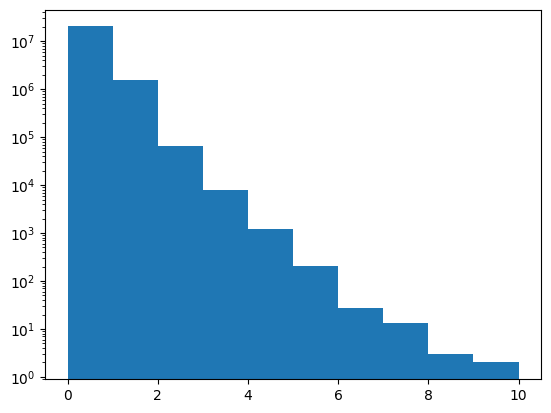

In [38]:
plt.hist(rq["n_np"],log=1);

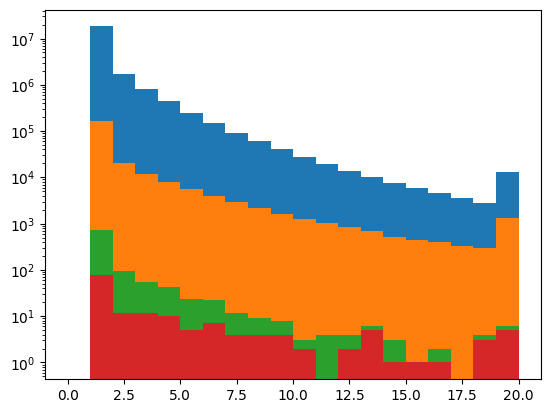

In [44]:
plt.hist(rq["n_cosmic"], bins=20, range=(0,20));
plt.hist(rq["n_cosmic"][rq["n_vertex"]>0], bins=20, range=(0,20));
plt.hist(rq["n_cosmic"][rq["n_vertex_upward"]>0], bins=20, range=(0,20));
plt.hist(rq["n_cosmic"][(rq["n_vertex_upward"]>0)&(rq["n_track_downward"]>1)], bins=20, range=(0,20));

# plt.hist(rq["n_vertex_upward"], bins=20, range=(0,20));
plt.yscale("log")